# Eddy hydrographic sections and 3-D ESP reconstruction

Select an eddy and optionally a day, then inspect native-level zonal and meridional sections of temperature, salinity, surface-referenced potential density, $N^2$, eastward velocity, northward velocity and speed. The final cells compare the background-removed SEACOFS velocity with the depth-dependent ESP reconstruction.

The saved N² cache contains eddy-core summary diagnostics rather than a spatial field. It is loaded for case-level validation; the plotted N² field is recalculated from source temperature and salinity with the same xroms potential-density method used by the v4 cache.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
REPO_ROOT = ANALYSIS_ROOT.parent
for path in (
    ANALYSIS_ROOT,
    ANALYSIS_ROOT / 'tilt_mechanisms',
    REPO_ROOT / 'seacofs_eddy_dataset_modular' / 'src',
    HERE,
):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
import case_section_tools as cst

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300})
pd.set_option('display.max_columns', 100)

## Controls

Set EDDY_ID. Set DAY=None to choose that eddy's deepest and best-resolved fitted day automatically.

In [2]:
EDDY_ID = 6
DAY = None

SECTION_FIELDS = ('N2', 'temp', 'salt', 'sigma0', 'u', 'v', 'speed')
MAX_SECTION_DEPTH_M = 1000.0
HORIZONTAL_SLICE_DEPTH_M = 200.0
HORIZONTAL_QUIVER_STEP = 5
HALF_WIDTH_RC = 2.25
MIN_HALF_WIDTH_KM = 80.0

REMOVE_BACKGROUND = True
BACKGROUND_OUTER_FRACTION = 0.72
ESP_ROOT = cst.DEFAULT_ESP_ROOT
N2_CACHE_PATH = cst.DEFAULT_N2_CACHE_PATH

## Load the selected eddy-day

In [3]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
surface_df, _ = tilt.load_tilt_tables(paths)
vertical_df = tilt.load_vert(paths, dic_form=False)

surface, profile, available_days = cst.choose_case(
    surface_df, vertical_df, EDDY_ID, DAY
)
case = cst.load_case(
    surface, profile, grid,
    half_width_rc=HALF_WIDTH_RC,
    minimum_half_width_km=MIN_HALF_WIDTH_KM,
)

display(pd.Series({
    'Eddy': int(surface.Eddy),
    'Day': int(surface.Day),
    'Polarity': surface.Cyc,
    'Fitted levels': len(profile),
    'Deepest fitted level (m)': profile.Depth.max(),
    'Source file': str(case.model_file),
}).to_frame('value'))
display(available_days.head(15))

,value
Eddy,6
Day,1462
Polarity,AE
Fitted levels,30
Deepest fitted level (m),4748.91767
Source file,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


,Eddy,Day,levels,maximum_depth_m
0,6,1462,30,4748.91767
1,6,1463,30,4748.91767
2,6,1464,30,4748.91767
3,6,1465,30,4748.91767
4,6,1466,30,4748.91767
5,6,1467,30,4748.91767
7,6,1469,30,4748.91767
10,6,1472,30,4748.91767
11,6,1473,30,4748.91767
13,6,1475,30,4748.91767


## Cached N² summary

These are the existing v4 potential-density core statistics for the selected eddy-day. They provide a consistency reference for the spatial N² sections below.

In [4]:
n2_summary = cst.load_n2_summary(surface.Eddy, surface.Day, N2_CACHE_PATH)
summary_columns = [
    name for name in n2_summary.index
    if name in {'Eddy', 'Day', 'N2_density_method', 'N2_cache_version'}
    or name.endswith('_core_s2')
    or name in {'N2_pycnocline_max_s2_core', 'pycnocline_depth_m_core', 'MLD_density_m_core'}
]
display(n2_summary[summary_columns].to_frame('value'))

,value
Eddy,6
Day,1462
N2_cache_version,v4_potential_density
N2_density_method,xroms.potential_density_z0
N2_200m_core_s2,0.000073
N2_500m_core_s2,0.000047
N2_pycnocline_max_s2_core,0.000143
pycnocline_depth_m_core,67.895315
MLD_density_m_core,37.399583


## Section location

The two dashed lines pass through the fitted surface centre. The centre's displacement with depth is overlaid on every vertical section.

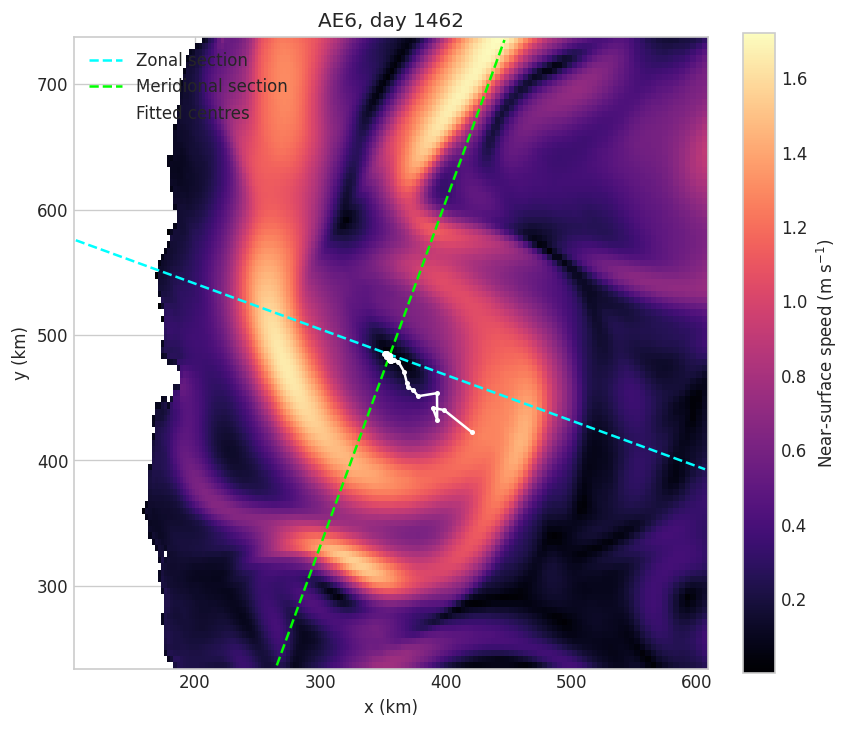

In [5]:
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
speed0 = np.hypot(case.u[:, :, -1], case.v[:, :, -1])
mesh = ax.pcolormesh(case.X, case.Y, speed0, cmap='magma', shading='auto')
fig.colorbar(mesh, ax=ax, label='Near-surface speed (m s$^{-1}$)')
_, zonal_x, zonal_y = cst.transect_xy(case, 'zonal')
_, meridional_x, meridional_y = cst.transect_xy(case, 'meridional')
ax.plot(zonal_x, zonal_y, color='cyan', ls='--', label='Zonal section')
ax.plot(meridional_x, meridional_y, color='lime', ls='--', label='Meridional section')
ax.plot(profile.xc, profile.yc, 'w.-', lw=1.5, ms=4, label='Fitted centres')
ax.set(
    xlabel='x (km)', ylabel='y (km)', aspect='equal',
    title=f'{surface.Cyc}{int(surface.Eddy)}, day {int(surface.Day)}',
)
ax.legend(frameon=False)
plt.show()

## Native-level hydrographic and velocity sections

These plots use true east–west and north–south lines through the surface centre. Fields are interpolated horizontally from the model grid onto each line, while the native sigma-level depths are retained at every position. No vertical interpolation is used here. Positive and negative $N^2$ are retained so unstable or noisy layers remain visible.

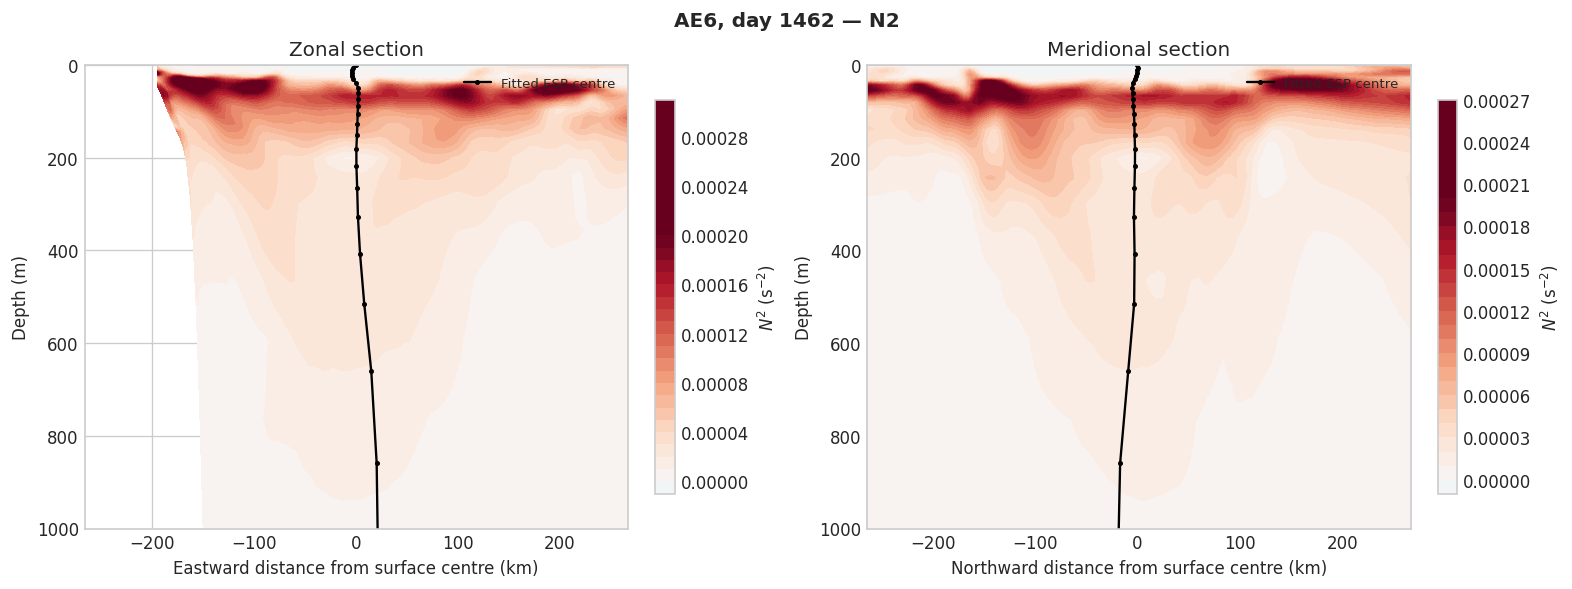

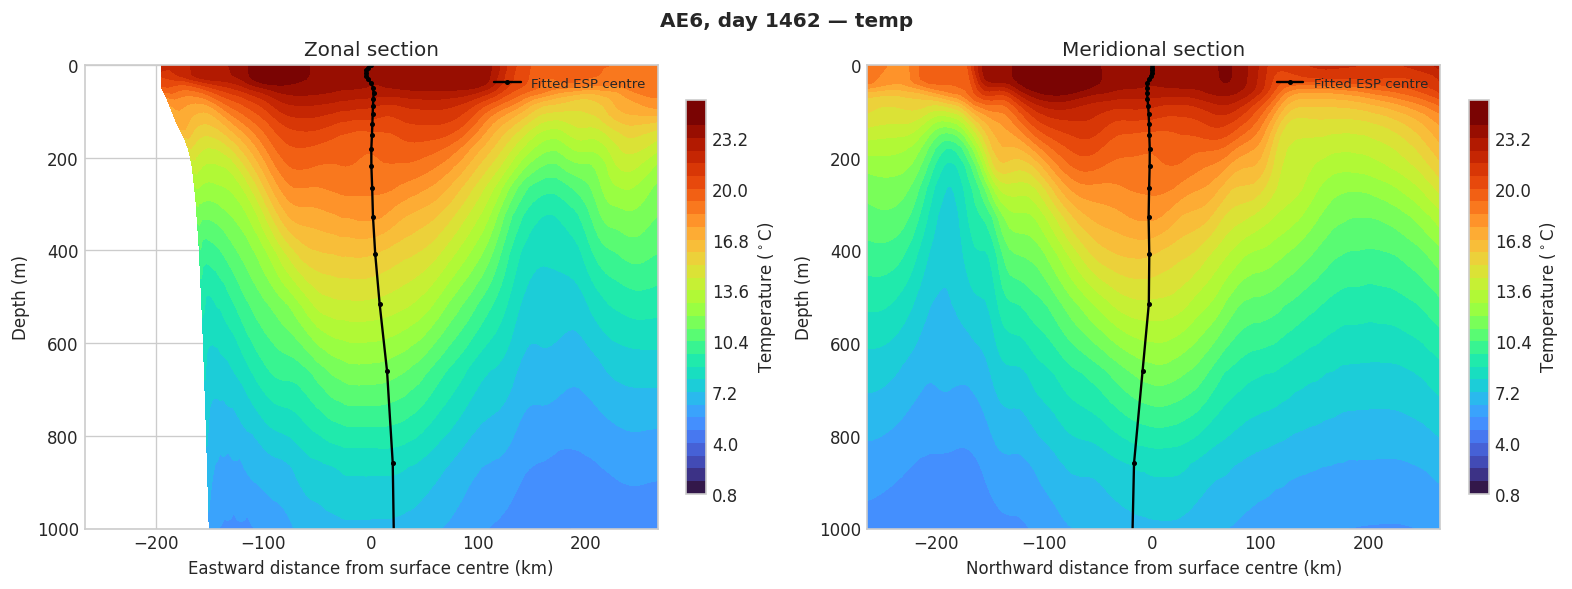

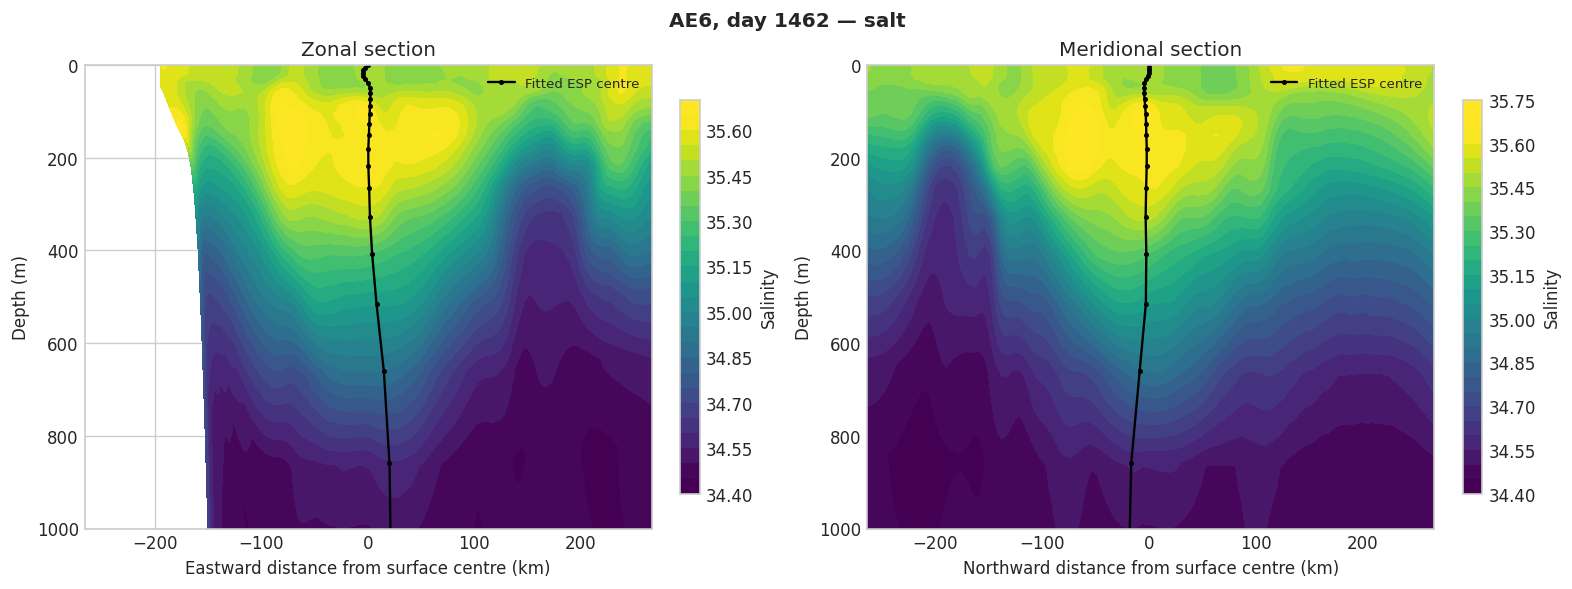

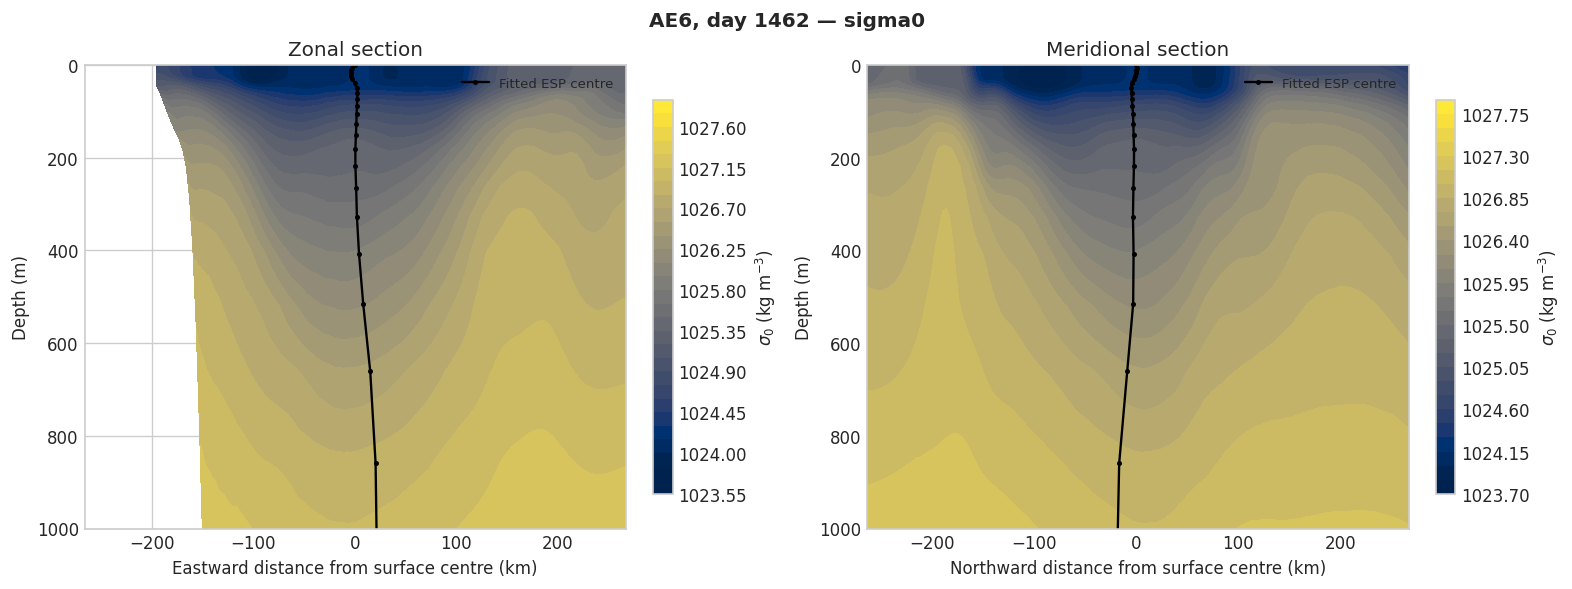

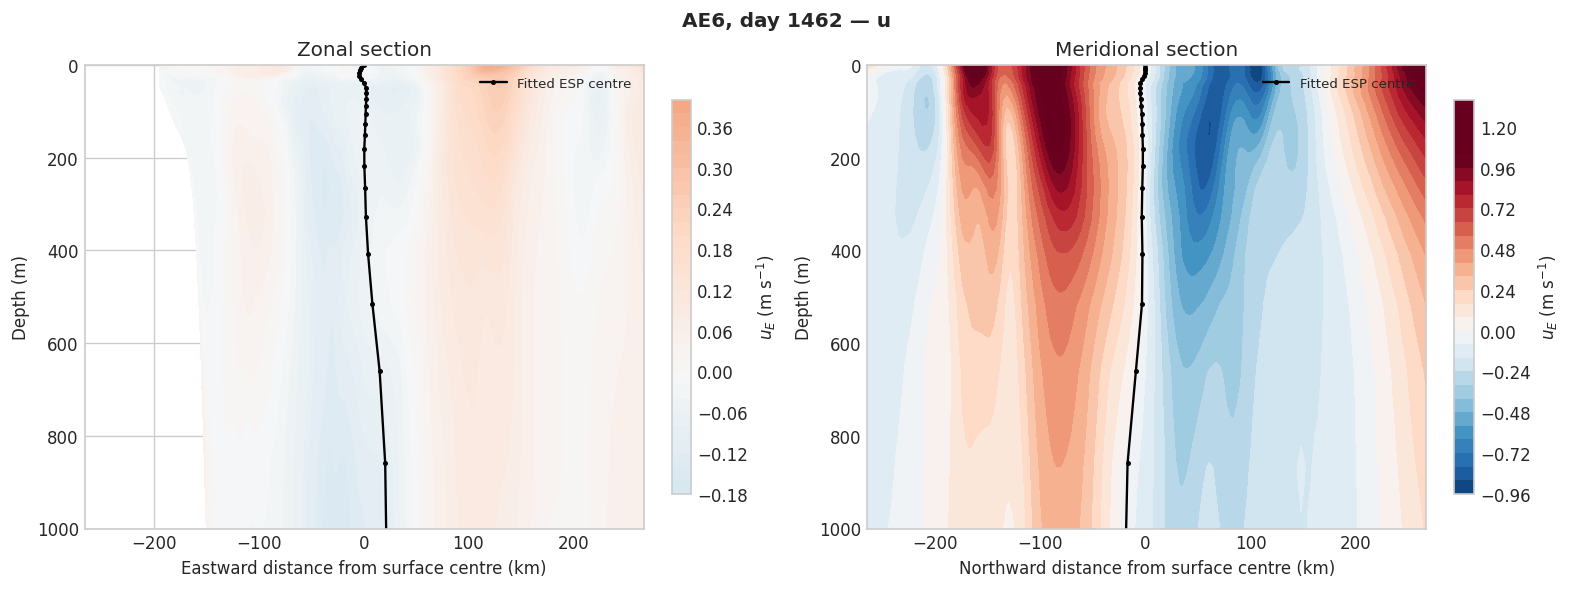

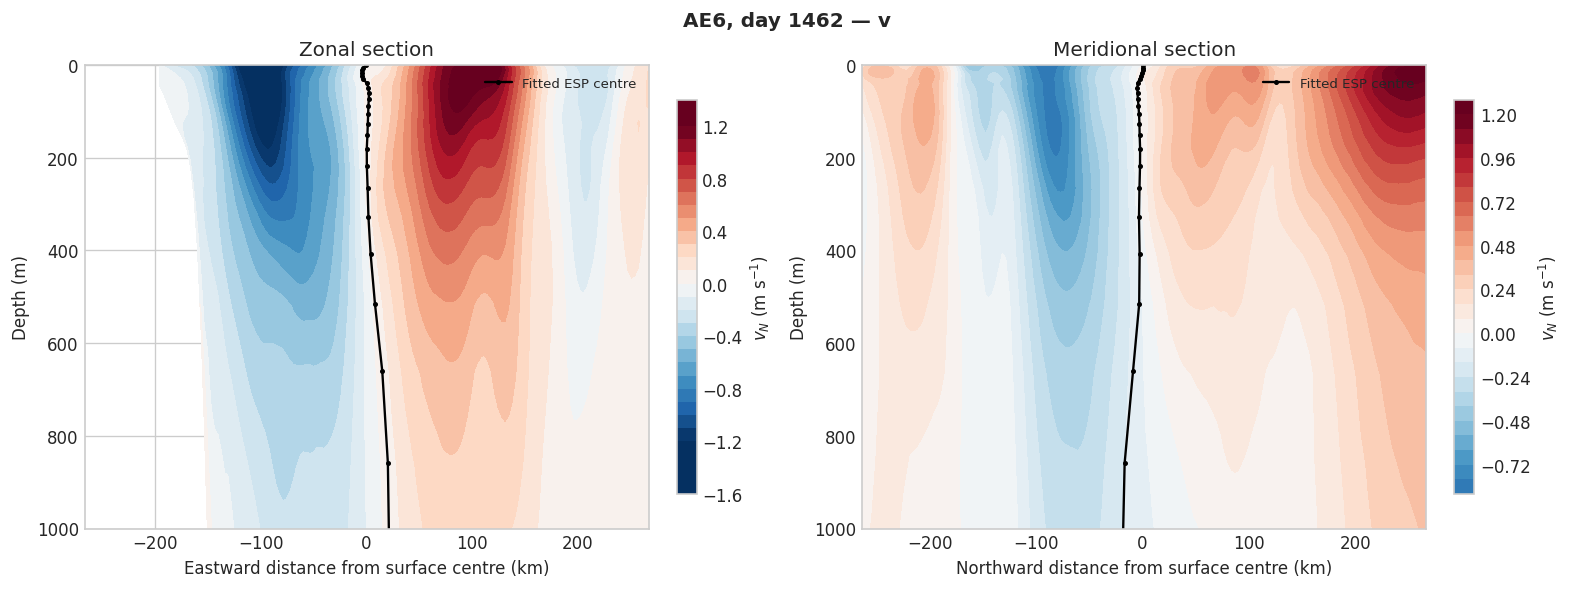

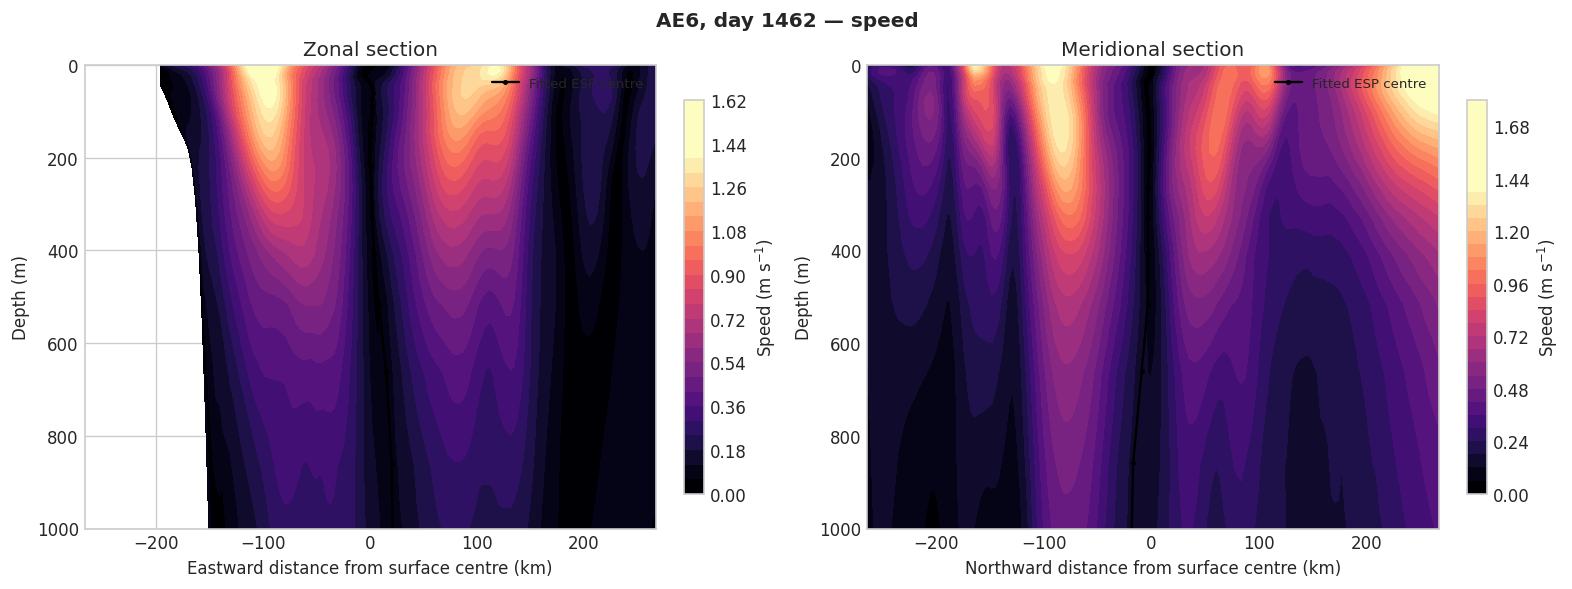

In [6]:
for field in SECTION_FIELDS:
    cst.plot_sections(case, field, max_depth_m=MAX_SECTION_DEPTH_M)
    plt.show()

## Reconstruct the depth-dependent ESP velocity field

ESP is evaluated from the fitted centre, ellipse tensor, angular velocity and core radius at every fitted depth. For a like-for-like comparison, native SEACOFS velocity is interpolated only to those fitted depths. A constant outer-box background vector can be removed independently at every level because ESP represents the coherent eddy component rather than the full regional circulation.

In [7]:
comparison = cst.reconstruct_esp(case, ESP_ROOT)
if REMOVE_BACKGROUND:
    (comparison.u_original, comparison.v_original,
     background_velocity) = cst.remove_outer_background(
        comparison.u_original, comparison.v_original,
        BACKGROUND_OUTER_FRACTION,
    )
else:
    background_velocity = np.zeros((len(comparison.depths), 2))

valid = np.isfinite(comparison.u_original) & np.isfinite(comparison.v_original)
comparison.u_esp = np.where(valid, comparison.u_esp, np.nan)
comparison.v_esp = np.where(valid, comparison.v_esp, np.nan)

background_table = pd.DataFrame({
    'Depth_m': comparison.depths,
    'background_u_m_s': background_velocity[:, 0],
    'background_v_m_s': background_velocity[:, 1],
})
display(background_table)
display(cst.esp_velocity_skill(comparison).style.format(precision=3))

/home/z5297792/UNSW-PhD/seacofs_eddy_tilt_analysis/case_studies/eddy_cross_sections_3d/case_section_tools.py:510: RuntimeWarning: All-NaN slice encountered
  background[k] = np.nanmedian(u[k][outer]), np.nanmedian(v[k][outer])


,Depth_m,background_u_m_s,background_v_m_s
0,0.000000,NaN,NaN
1,5.879627,0.022674,-0.096428
2,10.725783,0.012930,-0.077541
3,16.383097,-0.001678,-0.065771
4,22.925581,-0.011048,-0.063314
5,30.444118,-0.022678,-0.063897
6,39.052712,-0.028108,-0.066222
7,48.897638,-0.031301,-0.067784
8,60.170639,-0.035183,-0.068495
9,73.127842,-0.040113,-0.067747


,Depth_m,N,Vector_RMSE_m_s,Vector_NRMSE,u_correlation,v_correlation,speed_correlation
0,0.000,0,nan,nan,nan,nan,nan
1,5.880,14055,0.544,0.769,0.643,0.685,0.491
2,10.726,14055,0.541,0.768,0.644,0.690,0.496
3,16.383,14055,0.518,0.739,0.655,0.720,0.528
4,22.926,14055,0.512,0.738,0.657,0.720,0.530
5,30.444,14055,0.497,0.726,0.662,0.734,0.548
6,39.053,14048,0.485,0.717,0.660,0.748,0.566
7,48.898,14000,0.482,0.721,0.667,0.742,0.557
8,60.171,13929,0.479,0.723,0.667,0.738,0.554
9,73.128,13846,0.477,0.727,0.663,0.734,0.552


## ESP vertical-section comparison

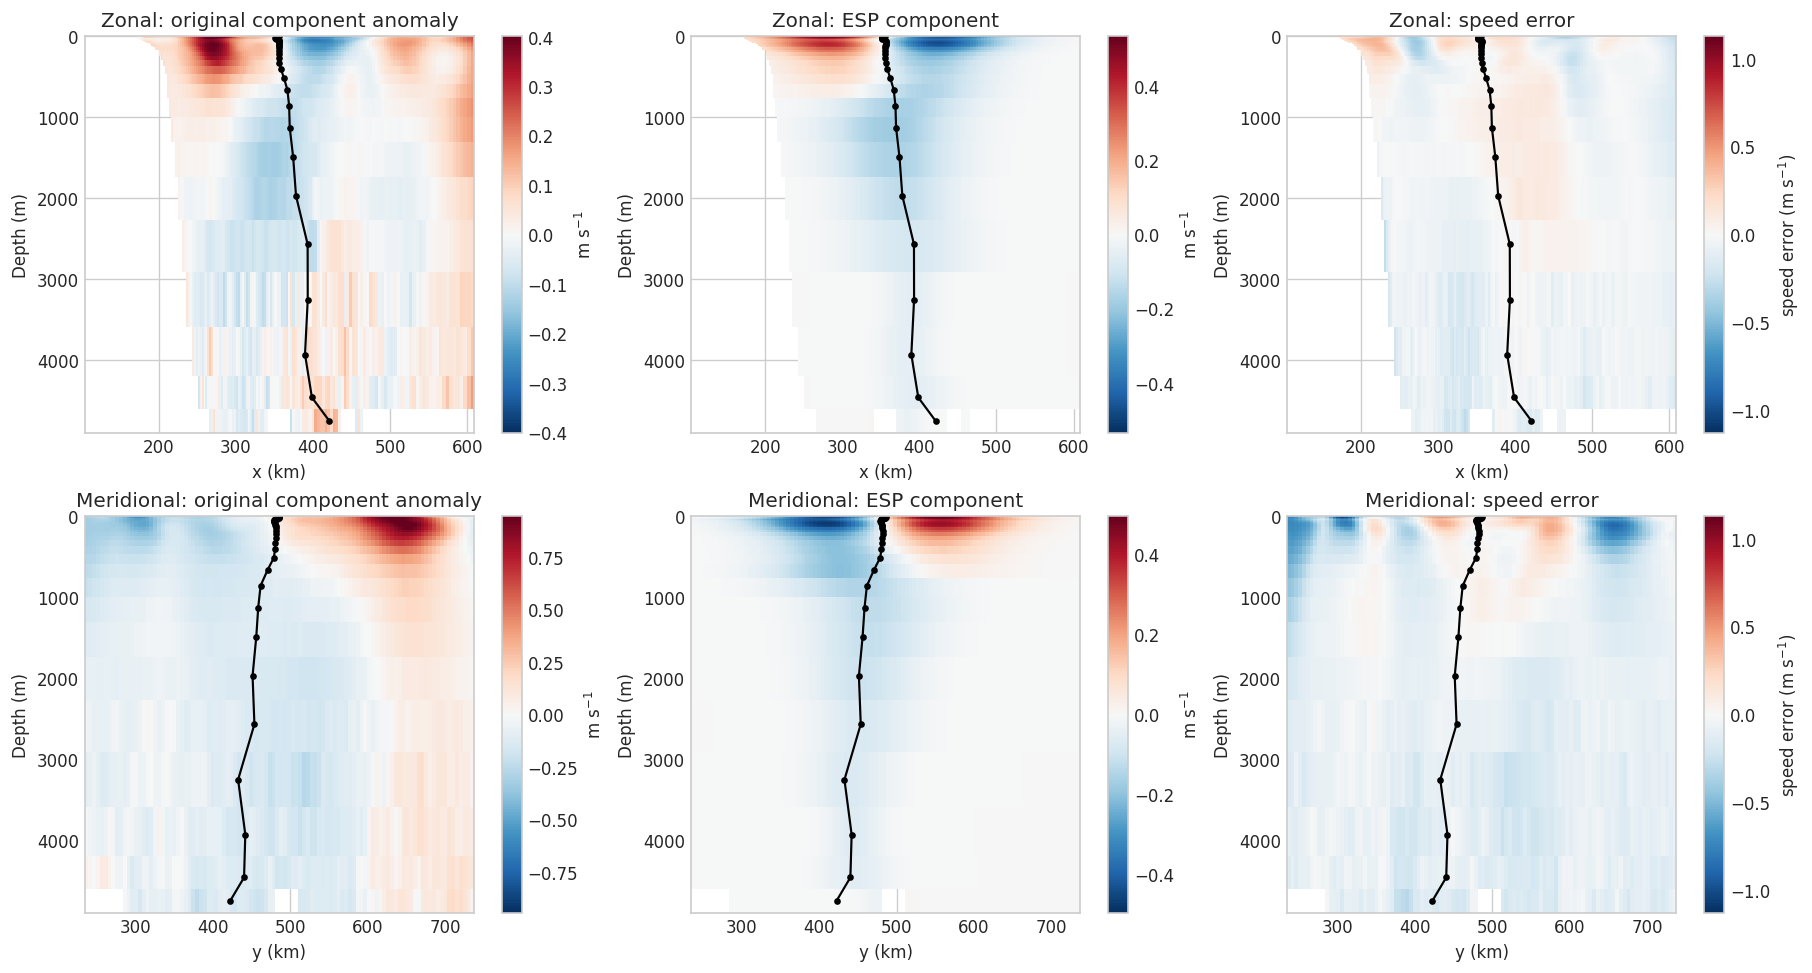

In [8]:
cst.plot_esp_sections(case, comparison)
plt.show()

## Selected horizontal velocity and relative-vorticity slice

The upper panels compare the background-removed original velocity anomaly with the ESP velocity at the fitted depth nearest `HORIZONTAL_SLICE_DEPTH_M`. The lower panels compare relative vorticity calculated from the original velocity curl with the corrected analytical ESP field, $\zeta=\nabla_h^2\psi$. Cyan marks the fitted `FRAC=1` core at that depth.


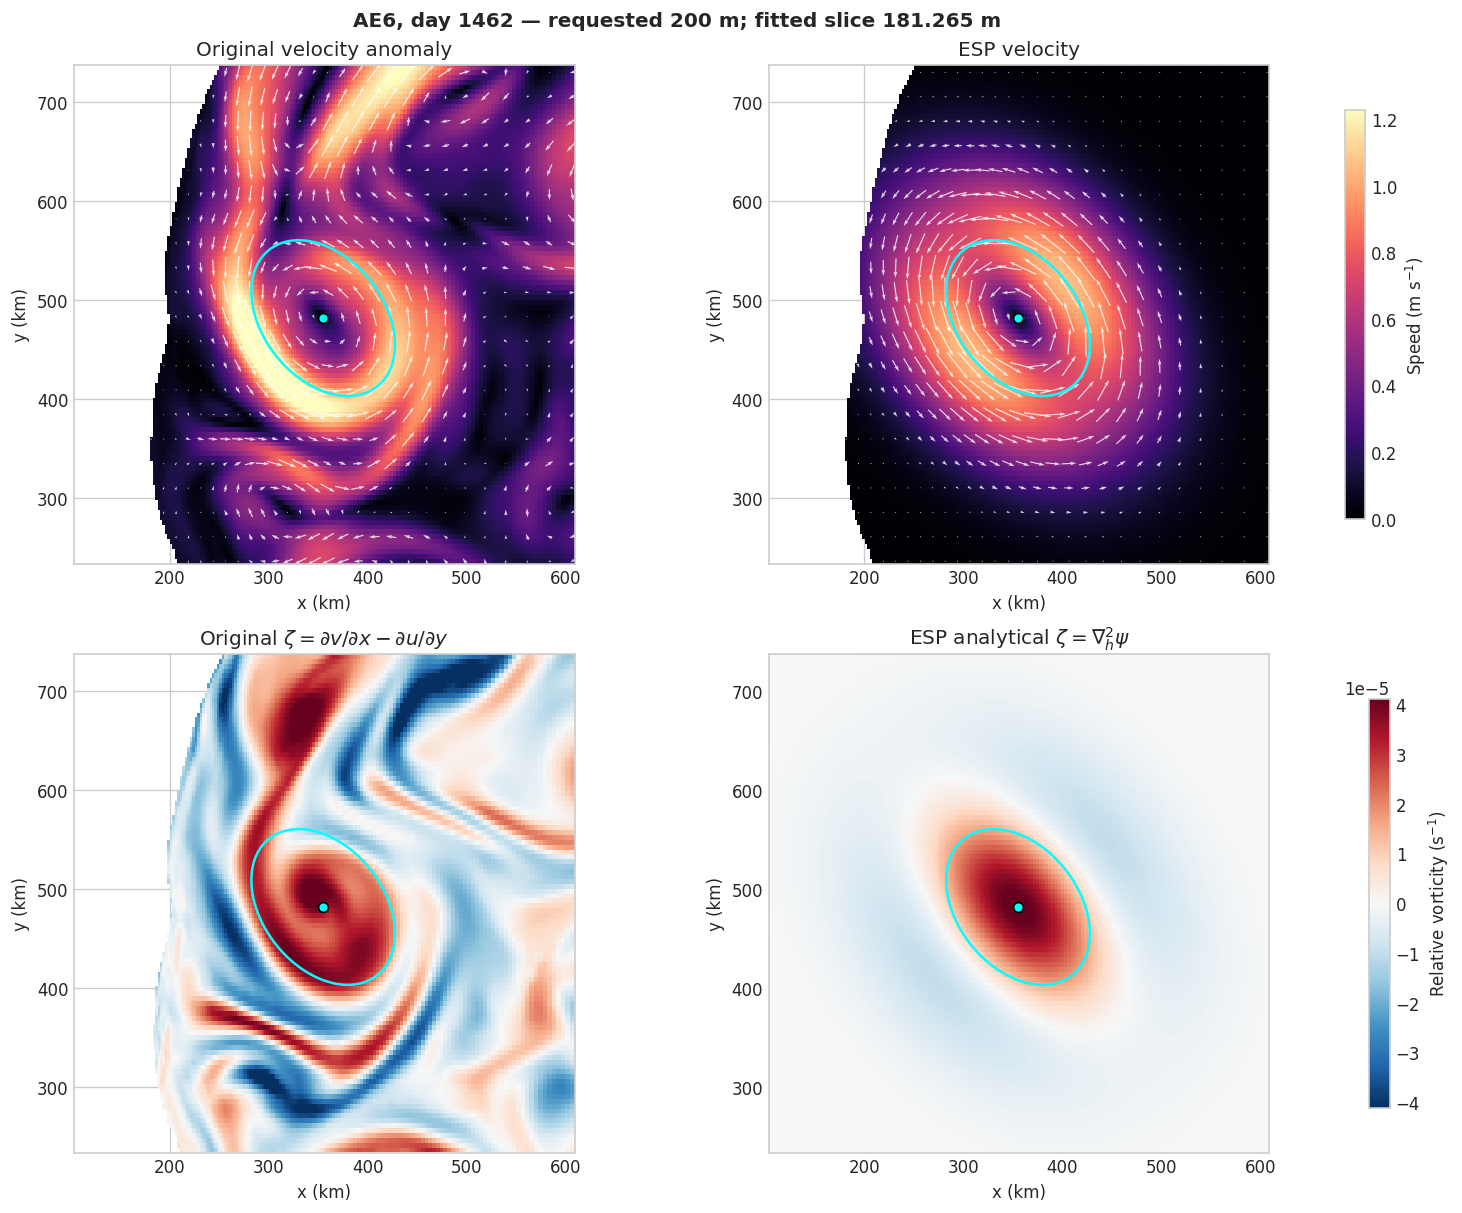

In [9]:
fig, axes, selected_slice_depth = cst.plot_horizontal_esp_comparison(
    case, comparison, HORIZONTAL_SLICE_DEPTH_M,
    quiver_step=HORIZONTAL_QUIVER_STEP,
)
plt.show()


## Three-dimensional velocity vectors

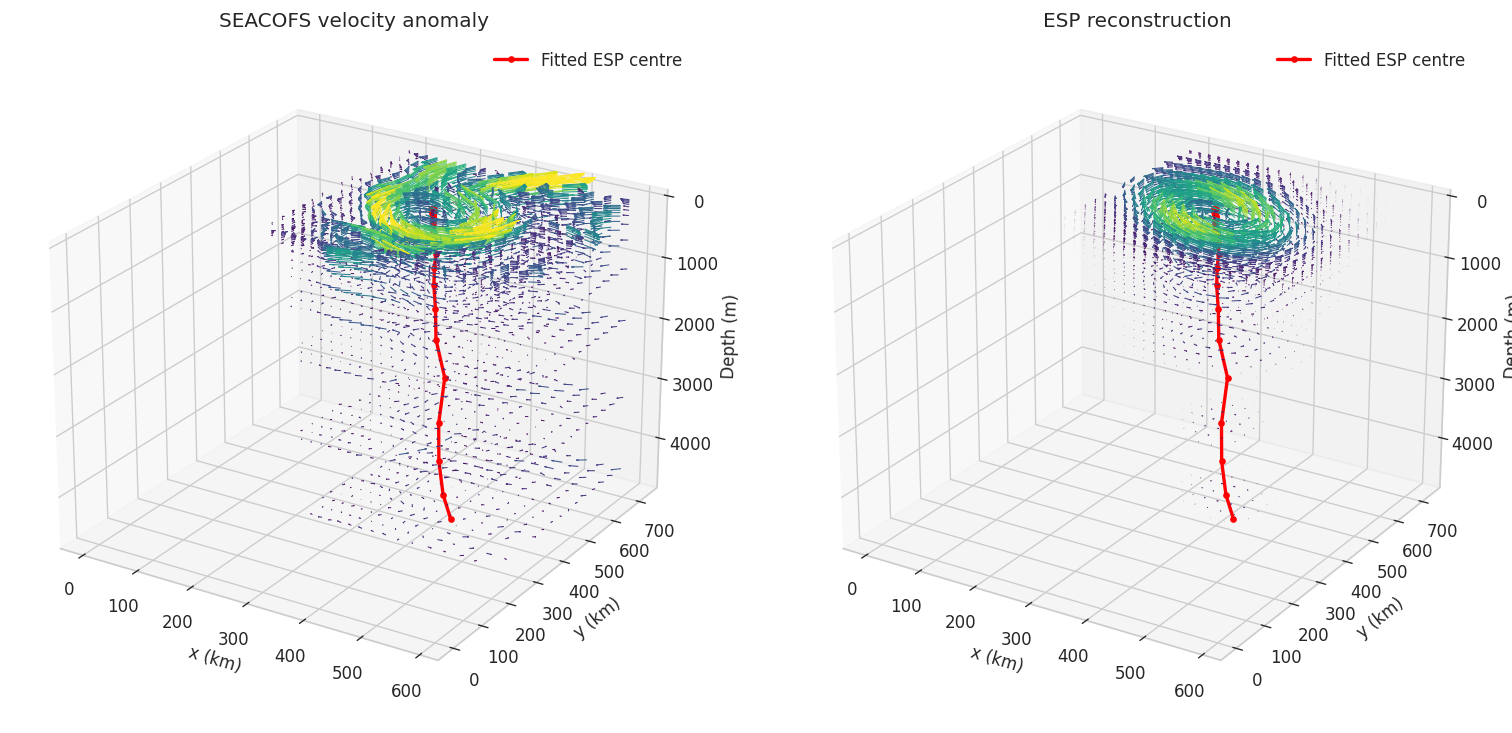

In [10]:
cst.plot_velocity_3d(case, comparison, xy_step=7, z_step=2)
plt.show()